## 03 - Construção de Modelo

In [8]:
# Manipulação e análise de dados
import pandas as pd 
import numpy as np 

# Visualização
import seaborn as sns
from matplotlib import pyplot as plt

# Serialização de objetos (salvar/carregar modelos/pipelines)
import joblib

# Construção de pipelines
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Pré-processamento
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, FunctionTransformer

# Seleção de features
from sklearn.feature_selection import RFECV, RFE

# Validação cruzada
from sklearn.model_selection import KFold, cross_validate

# Métricas
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# Modelos de regressão
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Logging (silencia avisos/infos para deixar output limpo)
import logging
logging.getLogger().setLevel(logging.CRITICAL)

# Transformer customizado (definido em Utils/transformers.py)
from Utils.transformers import LogTransformer
import warnings
warnings.filterwarnings("ignore")


### Leitura dos dados de treinamento transformados

In [9]:
df_train = pd.read_csv('./Data/train.csv')
X_train = df_train.drop(columns=['MEDV'])
y_train = df_train['MEDV']

# carrega depois
with open("./Data/X_train_columns.txt", "r") as f:
    saved_columns = [line.strip() for line in f.readlines()]
    

In [10]:
# carregar pipeline do arquivo
pipe_loaded = joblib.load("./Utils/pipeline_tratamento.pkl")

# usar direto no teste
X_train_transformed = pipe_loaded.transform(X_train[saved_columns])

In [11]:
X_train_transformed

,LSTAT,RAD,RM,PTRATIO,LSTAT^2,LSTAT RAD,LSTAT RM,LSTAT PTRATIO,RAD^2,RAD RM,RAD PTRATIO,RM^2,RM PTRATIO,PTRATIO^2
0,0.719380,1.000000,0.494384,0.878049,0.571524,0.762723,0.693779,0.732675,1.000000,0.826999,1.000000,0.389319,0.645578,0.852375
1,0.574203,0.506422,0.596631,0.414634,0.395131,0.324095,0.612143,0.458742,0.256464,0.454979,0.411155,0.495476,0.463136,0.356440
2,0.888862,1.000000,0.337529,0.878049,0.816508,0.906027,0.721929,0.894127,1.000000,0.717435,1.000000,0.243545,0.440753,0.852375
3,0.672134,0.345687,0.444423,0.682927,0.510731,0.249854,0.608560,0.623169,0.119500,0.273819,0.318306,0.340642,0.463046,0.631008
4,0.666707,0.506422,0.488381,0.804878,0.503956,0.363705,0.635499,0.658464,0.256464,0.416687,0.491380,0.383359,0.592050,0.767223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,0.779101,0.506422,0.462820,0.414634,0.653049,0.411833,0.728637,0.617212,0.256464,0.407645,0.411155,0.358322,0.321273,0.356440
340,0.417224,0.436209,0.717661,0.560976,0.239138,0.221261,0.500439,0.371281,0.190278,0.428774,0.380063,0.632495,0.700614,0.501926
341,0.675957,0.345687,0.501936,0.585366,0.515529,0.250971,0.654967,0.594129,0.119500,0.287706,0.304615,0.396859,0.470579,0.527172
342,0.712411,0.436209,0.470372,0.975610,0.562351,0.330136,0.668083,0.759806,0.190278,0.353427,0.453484,0.365662,0.674210,0.969904


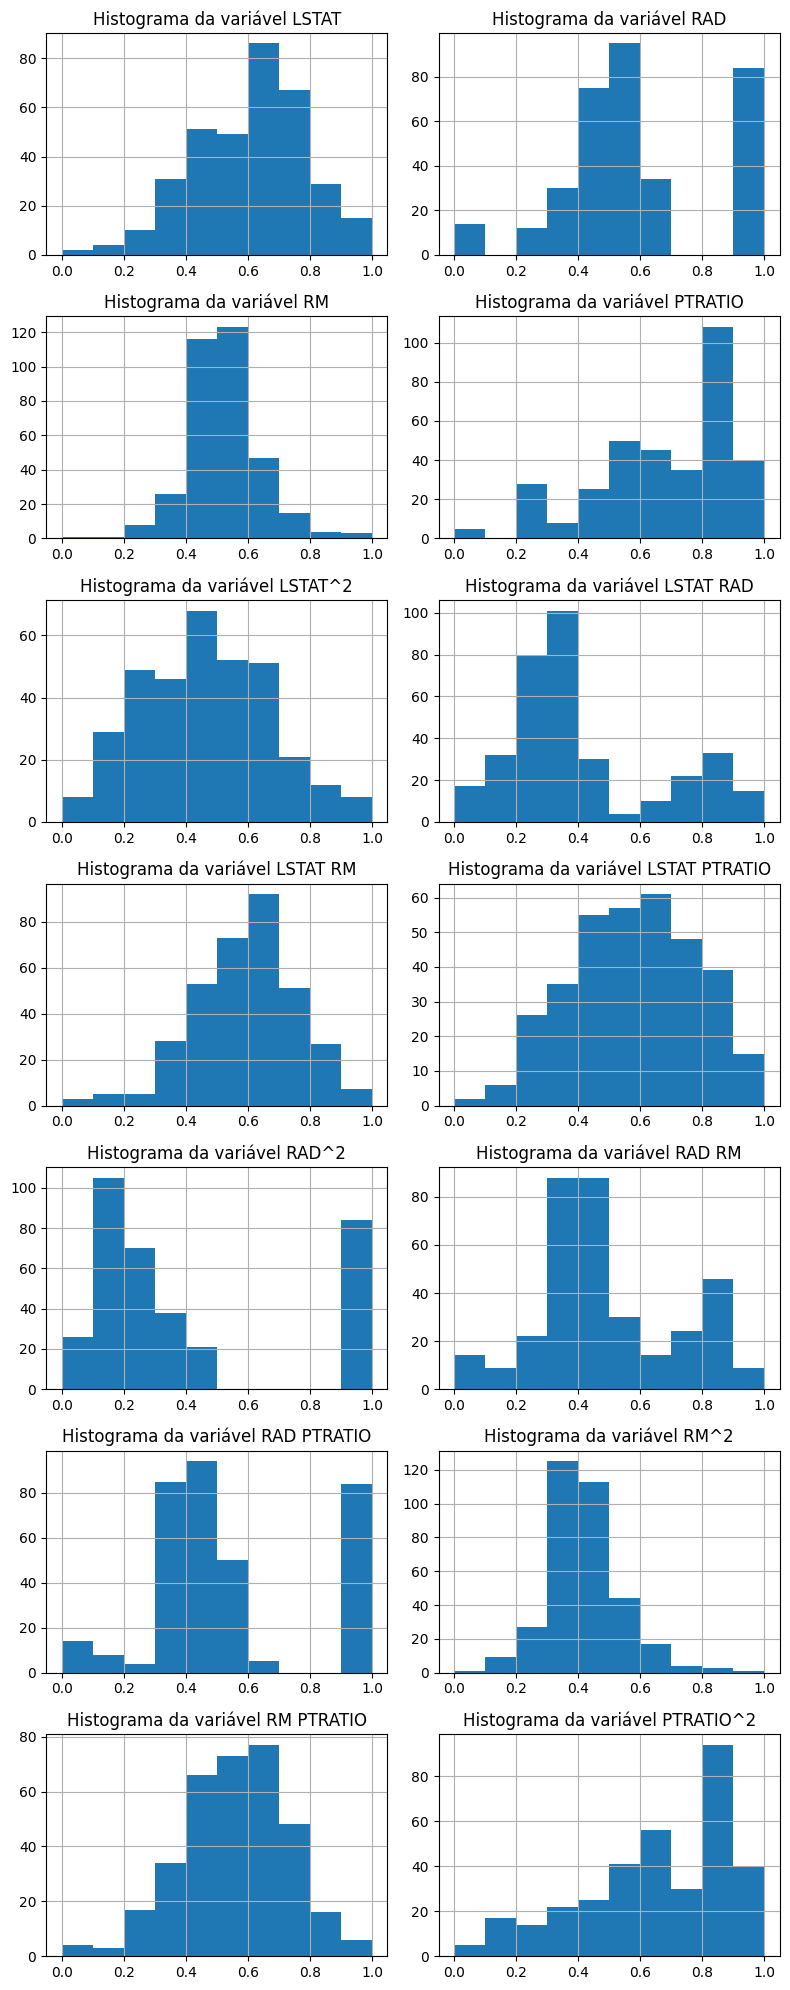

In [12]:
# Cria uma grade de subplots: 1 coluna e uma linha para cada variável
fig, axs = plt.subplots(7, 2, figsize=(8, 20))

# Plota um histograma por variável
for col, ax in zip(X_train_transformed.columns, axs.flatten()):
    X_train_transformed[col].hist(bins=10, ax=ax)
    ax.set_title(f'Histograma da variável {col}')

# Ajusta layout para não sobrepor títulos
plt.tight_layout()


## Competição de modelos

In [13]:
# Definição das métricas de avaliação
scoring = {
    'r2': 'r2',                                  # Coeficiente de determinação (quanto maior, melhor)
    'mse': make_scorer(mean_squared_error),      # Mean Squared Error (quanto menor, melhor)
    'mae': make_scorer(mean_absolute_error)      # Mean Absolute Error (quanto menor, melhor)
}

def model_competition_cv(X_train, y_train, dict_model, cv_splits=5, random_state=42):
    """
    Executa validação cruzada (cross-validation) para comparar múltiplos modelos.
    Retorna um DataFrame com as médias e desvios padrão das métricas R2, MSE e MAE.
    """
    results = []

    # Cria esquema de cross-validation (KFold estratificado e com embaralhamento)
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    # Loop pelos modelos do dicionário
    for name, model in dict_model.items():
        # Executa cross-validation e coleta métricas
        cv_out = cross_validate(
            model, 
            X_train, 
            y_train,
            scoring=scoring,   # usa as métricas definidas acima
            cv=cv,             # validação cruzada
            n_jobs=-1,         # usa todos os núcleos disponíveis
            return_train_score=False
        )

        # --- Agregação das métricas ---
        # R²
        r2_mean = np.mean(cv_out['test_r2'])
        r2_std  = np.std(cv_out['test_r2'])

        # MSE
        mse_vals = cv_out['test_mse']
        mse_mean = np.mean(mse_vals)
        mse_std  = np.std(mse_vals)

        # MAE
        mae_vals = cv_out['test_mae']
        mae_mean = np.mean(mae_vals)
        mae_std  = np.std(mae_vals)

        # Armazena resultados do modelo
        results.append({
            'Model': name,
            'R2 (cv mean)': round(r2_mean, 4),
            'R2 (cv std)':  round(r2_std, 4),
            'MSE (cv mean)': round(mse_mean, 4),
            'MSE (cv std)':  round(mse_std, 4),
            'MAE (cv mean)': round(mae_mean, 4),
            'MAE (cv std)':  round(mae_std, 4),
        })

    # Retorna DataFrame ordenado pelo R² médio (do melhor para o pior)
    df = pd.DataFrame(results).sort_values(by='R2 (cv mean)', ascending=False).reset_index(drop=True)
    return df


# --- Definição dos modelos para comparação ---
dict_model = {
    'Linear Regression': LinearRegression(), 
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42), 
    'Random Forest Regressor': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGB Regressor': XGBRegressor(random_state=42, n_estimators=300, learning_rate=0.05, n_jobs=-1),
}

# Executa a comparação dos modelos via cross-validation
cv_report = model_competition_cv(X_train_transformed, y_train, dict_model, cv_splits=5, random_state=42)

# Mostra resultados arredondados
round(cv_report, 2)

,Model,R2 (cv mean),R2 (cv std),MSE (cv mean),MSE (cv std),MAE (cv mean),MAE (cv std)
0,Random Forest Regressor,0.77,0.03,13.94,2.83,2.56,0.13
1,Linear Regression,0.76,0.06,14.07,1.92,2.60,0.13
2,XGB Regressor,0.75,0.04,15.26,4.16,2.66,0.15
3,Decision Tree Regressor,0.50,0.15,29.56,11.25,3.74,0.46


Baseado nos resultados, selecionamos Random Forest Regressor por apresentar o maior valor médio de R2 e menor desvio padrão para essa métrica nas saida do Cross Validation

In [14]:
from sklearn.feature_selection import RFE

# Pipeline: pré-processamento -> RFE -> RandomForest final
pipe = Pipeline([
    ('pipe_loaded', pipe_loaded),  # transforma dados (imputer, scaler, OHE etc.)
    ('rfe', RFE(
        estimator=RandomForestRegressor(
            min_samples_leaf=2,    # fixa o valor de min_samples_leaf = 2
            random_state=42,
            n_jobs=-1              # usa todos os núcleos
        ),
        step=1                     
    )),
    ('model', RandomForestRegressor(
        min_samples_leaf=2,        # mesma regularização
        random_state=42,
        n_jobs=-1
    ))
])

# Treino do pipeline
pipe.fit(X_train[saved_columns], y_train)

# Nomes das features após pré-processamento
feat_names = pipe.named_steps['pipe_loaded'].get_feature_names_out()

# Máscara de seleção do RFE
mask = pipe.named_steps['rfe'].support_
selected_names = np.array(feat_names)[mask]

# Importâncias do RF final (somente nas selecionadas)
imps = pipe.named_steps['model'].feature_importances_
pd.Series(imps, index=selected_names).sort_values(ascending=False)


LSTAT PTRATIO    0.361453
RM^2             0.243055
RM               0.191776
LSTAT RAD        0.072916
LSTAT            0.072753
LSTAT^2          0.032428
RAD RM           0.025618
dtype: float64

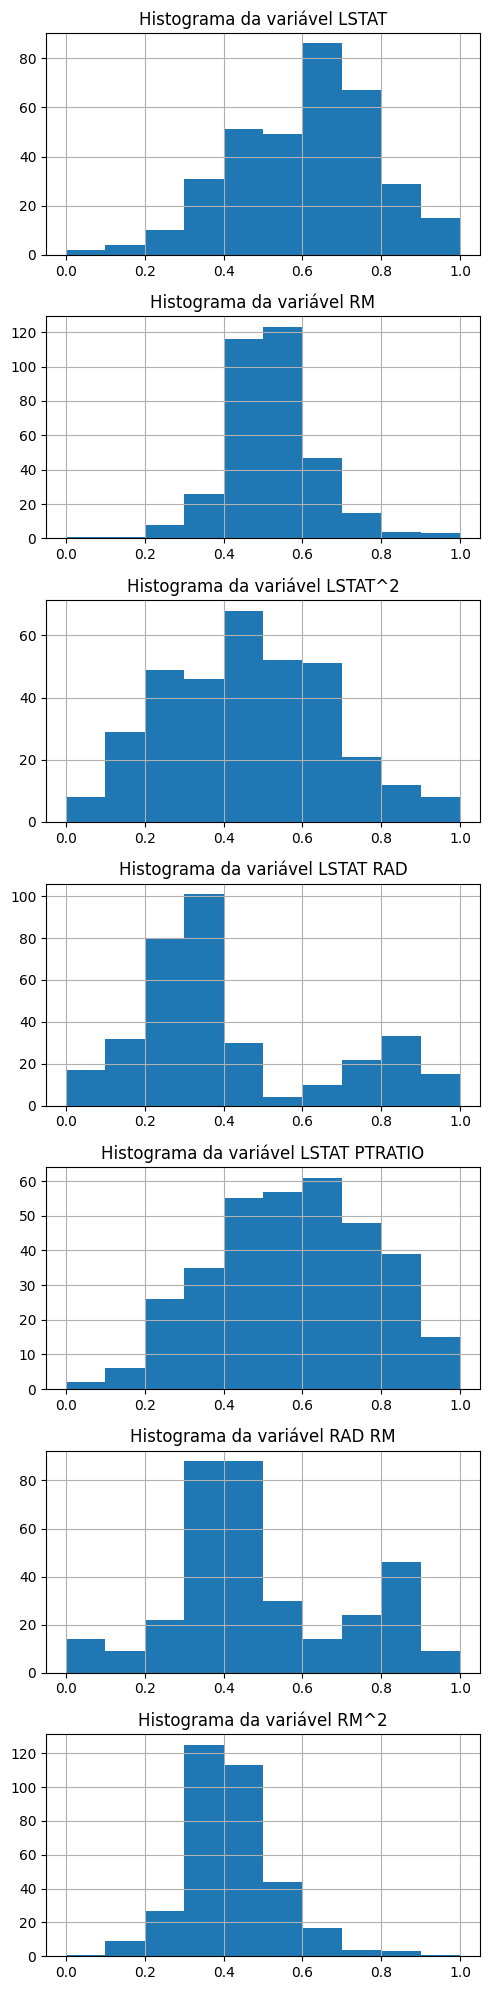

In [15]:
# Cria uma grade de subplots: 1 coluna e uma linha para cada variável
fig, axs = plt.subplots(len(selected_names), 1, figsize=(5, 20))

# Plota um histograma por variável
for col, ax in zip(selected_names, axs.flatten()):
    X_train_transformed[col].hist(bins=10, ax=ax)
    ax.set_title(f'Histograma da variável {col}')

# Ajusta layout para não sobrepor títulos
plt.tight_layout()


In [16]:
# Salvar pipeline em arquivo
joblib.dump(pipe, "./Utils/pipeline_modelo.pkl")


['./Utils/pipeline_modelo.pkl']